In [2]:
# load settings
import re
import typing as t
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)  # For reproducibility

In [28]:
class PlotSettings:
    """Class to manage plot styling and configuration."""

    COLORS: dict[str, str] = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {"CHILDES": "-", "child": "-", "LSTM": "-", "trans": "-."}

    DEFAULTS = {"label_fontsize": 18, "linewidth": 3, "title_fontsize": 28, "grid_color": "#bbbbbb", "figsize": (10, 6), "default_fill_alpha": 0.25}

    FILL_ALPHA: dict[str, float] = {
        "before": 0.1,
        "after": 0.5,
    }

    @classmethod
    def configure_plot(cls, title: str = None, model: str = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=cls.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=cls.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=cls.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=cls.DEFAULTS["grid_color"])

    @classmethod
    def configure_legend(cls) -> None:
        """Configure legend settings."""
        plt.legend(title="Settings", title_fontsize=cls.DEFAULTS["title_fontsize"], fontsize=cls.DEFAULTS["title_fontsize"], loc="upper left", bbox_to_anchor=(1.1, 1))

    @classmethod
    def save_figure(cls, filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

    @classmethod
    def get_color_palette(cls, n_colors: int) -> list[str]:
        """Get a color palette for the given number of colors."""
        return sns.color_palette("husl", n_colors=n_colors).as_hex()

    @classmethod
    def apply_style_to_axis(cls, ax: plt.Axes, title: str | None = None) -> None:
        """Apply styling to an existing axis."""
        if title:
            ax.set_title(title, fontsize=cls.DEFAULTS["title_fontsize"])
        ax.tick_params(labelsize=cls.DEFAULTS["label_fontsize"])
        ax.grid(True, linestyle=":", linewidth=1, color=cls.DEFAULTS["grid_color"])


def get_color_mapping(unique_conditions: list[str], plot_settings: PlotSettings) -> dict[str, str]:
    """Create color mapping for each condition."""
    extra_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_conditions)))
    return {cond: plot_settings.COLORS.get(cond, extra_colors[i]) for i, cond in enumerate(unique_conditions)}


def extract_style(text: str) -> str:
    """Extract text inside parentheses. Returns empty string if no parentheses found."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""

# Freq match

In [4]:
def get_freq(df):
    """Annotate freq of the given column."""
    if not "freq" in df.columns:
        df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
    df["log_freq"] = np.log10(df["freq"] + 1e-10)
    df = df.dropna()
    return df

In [5]:
def plot_distributions(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    bin_header: str | None = None,
    output_path: Path | None = None,
    kind: t.Literal["hist", "kde"] = "kde",
    title: str | None = None,
) -> None:
    """Plot distributions of a specific column from multiple dataframes on the same figure."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])

    for name, df in dataframes.items():
        color = PlotSettings.COLORS.get(name.split("_")[0], "gray")
        fill_alpha = PlotSettings.FILL_ALPHA.get(name.split("_")[1], PlotSettings.DEFAULTS["default_fill_alpha"])

        if kind == "hist":
            df = df.sort_values(by=column, ascending=True)
            if bin_header:
                # Calculate bin edges based on bin_nb column
                data_grouped = df.groupby(bin_header)

                # Get min value for first edge
                bin_edges = [df[column].min()]  # Start with overall minimum

                # Add maximum value of each group
                for _, group_data in data_grouped:
                    bin_edges.append(group_data[column].max())
                plt.hist(df[column], bins=bin_edges, alpha=fill_alpha, color=color, edgecolor=color, linestyle=PlotSettings.LINESTYLES.get(name, "-"), label=name, density=True)
            else:
                # Default to automatic binning if bin_nb not available
                plt.hist(df[column], bins="auto", alpha=fill_alpha, color=color, edgecolor=color, linestyle=PlotSettings.LINESTYLES.get(name, "-"), label=name, density=True)
        else:
            sns.kdeplot(
                data=df[column],
                color=color,
                linestyle=PlotSettings.LINESTYLES.get(name, "-"),
                label=name,
                linewidth=PlotSettings.DEFAULTS["linewidth"],
                fill=True,
                alpha=fill_alpha,
            )
    # Apply styling
    plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    # Customize axes
    plt.xlabel(column, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(
        # "Density" if kind == "kde" else "Normalized Frequency",
        "Density",
        fontsize=PlotSettings.DEFAULTS["label_fontsize"],
    )
    if title:
        plt.title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], pad=20)
    # Adjust ticks
    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    # Configure legend
    plt.legend(
        title="Dataset",
        title_fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        framealpha=0.9,
        edgecolor="black",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )
    # Adjust layout
    plt.figure(figsize=(12, 6))
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, bbox_inches="tight", dpi=300)
        plt.close()
    else:
        plt.show()

In [6]:
def compare_distr(file_root, freq_root, cdi_path):
    """Compare distribution before and after matching."""
    # all the raw datasets
    childes = pd.read_csv(f"{freq_root}/childes_adult.csv")
    childes = get_freq(childes)

    stela = pd.read_csv(f"{freq_root}/stela_bm_60_00.csv")
    stela = get_freq(stela)

    child_realistic = pd.read_csv(f"{freq_root}/childrealistic_bm_60_00.csv")
    child_realistic = get_freq(child_realistic)

    # all the matched files
    human_cdi = pd.read_csv(cdi_path)
    human_cdi = get_freq(human_cdi)

    stela_cdi = pd.read_csv(f"{file_root}/stela_matched_cdi.csv")
    stela_cdi = get_freq(stela_cdi)

    realistic_cdi = pd.read_csv(f"{file_root}/human_realistic_matched_cdi.csv")
    realistic_cdi = get_freq(realistic_cdi)

    # plot the original distirbution
    condition1 = "before"
    condition2 = "after"
    dataframes = {
        f"CHILDES_{condition1}": childes,
        f"stela_{condition1}": stela,
        f"child_{condition1}": child_realistic,
        f"CHILDES_{condition2}": human_cdi,
        f"stela_{condition2}": stela_cdi,
        f"child_{condition2}": realistic_cdi,
    }
    # Test both plot types
    plot_distributions(dataframes, column="log_freq", bin_header="bin_nb", kind="kde", title=f"Log Freq {condition1} and {condition2} matching")

    # plot the original distirbution
    dataframes = {"CHILDES_after": human_cdi, "stela_after": stela_cdi, "child_after": realistic_cdi}
    # Test both plot types
    plot_distributions(dataframes, column="log_freq", bin_header="bin_nb", kind="hist", title="Matched log freq by bins")


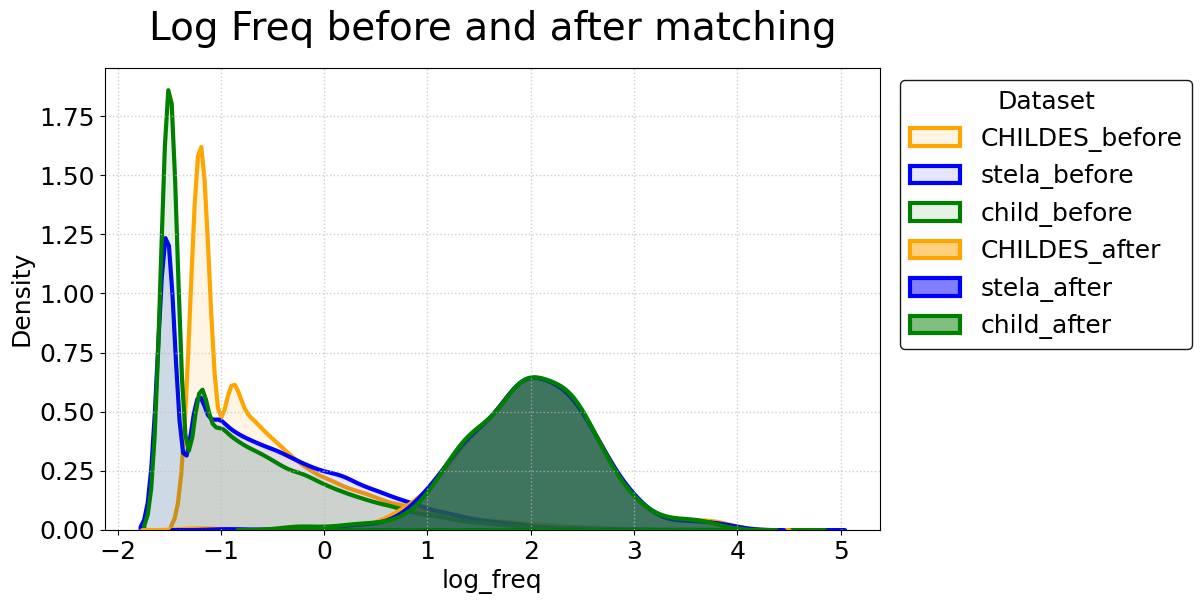

<Figure size 1200x600 with 0 Axes>

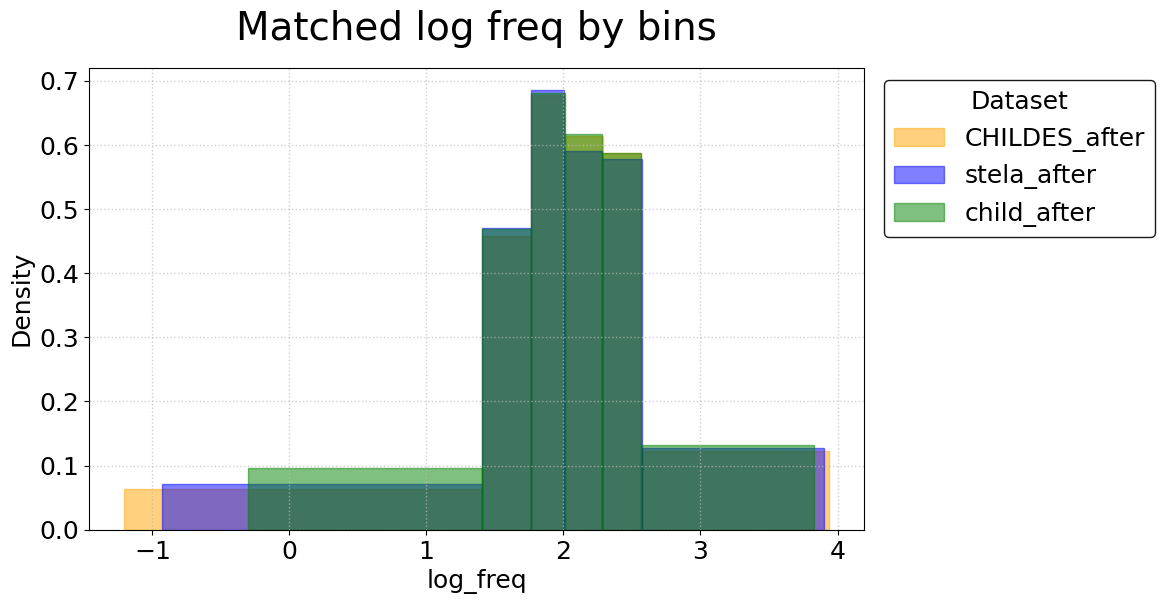

<Figure size 1200x600 with 0 Axes>

In [314]:
# load file
sampling_ratio = 1
file_root = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}"
freq_root = "/Users/jliu/workspace/lexical_bencmark/dataset/word_freq"
cdi_path = "/Users/jliu/workspace/lexical_bencmark/dataset/cdi_ws_na_childes.csv"
compare_distr(file_root, freq_root, cdi_path)

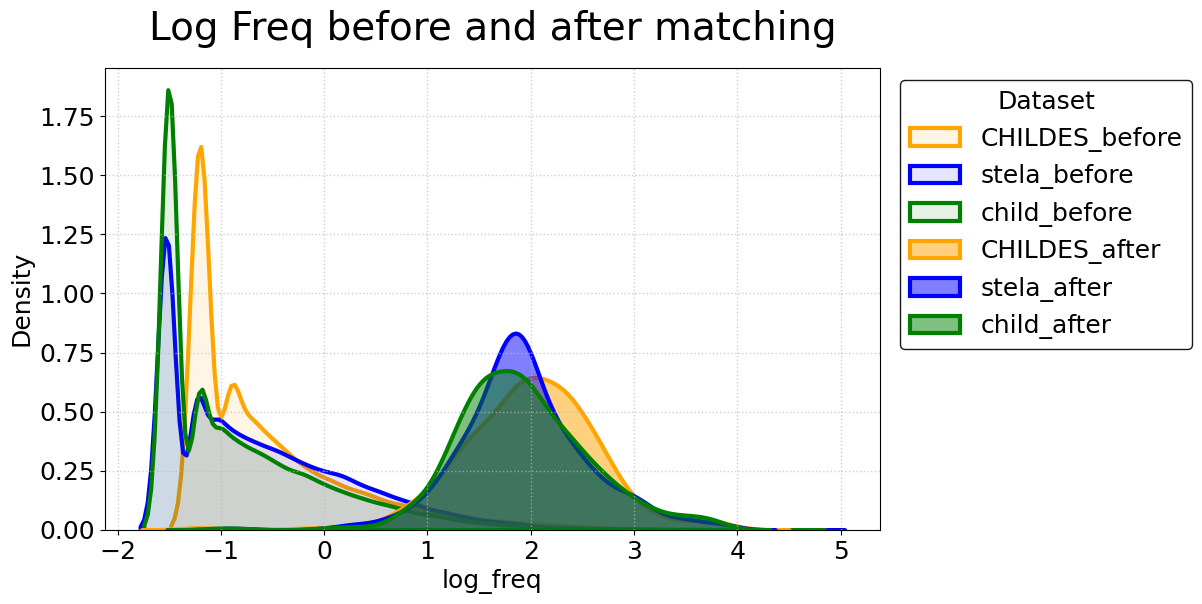

<Figure size 1200x600 with 0 Axes>

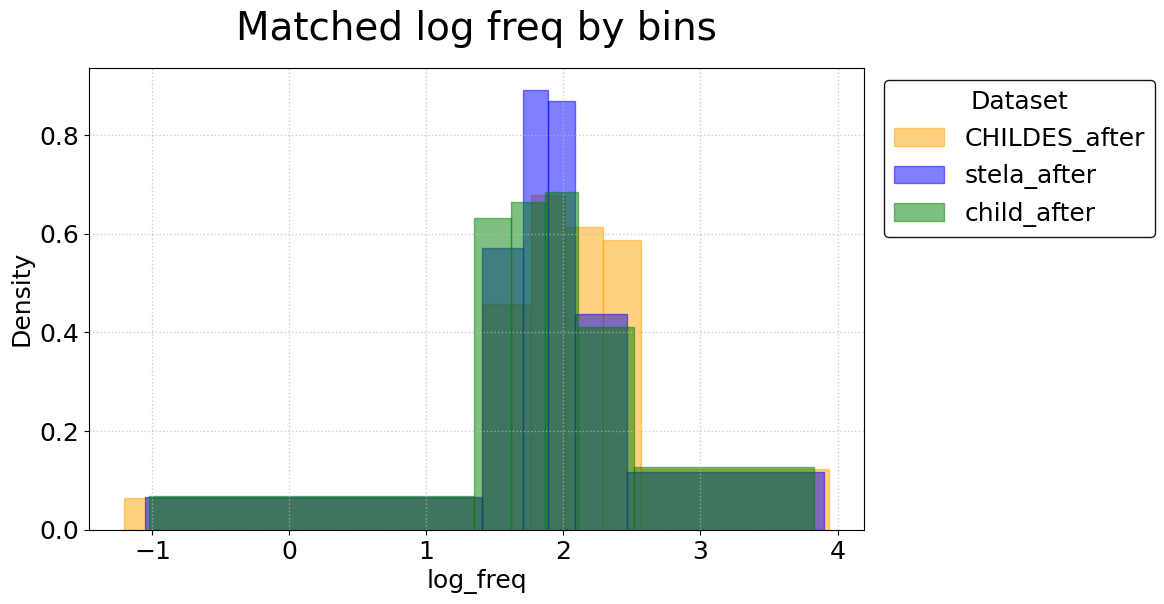

<Figure size 1200x600 with 0 Axes>

In [324]:
# load file
sampling_ratio = 2
file_root = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}"
freq_root = "/Users/jliu/workspace/lexical_bencmark/dataset/word_freq"
cdi_path = "/Users/jliu/workspace/lexical_bencmark/dataset/cdi_ws_na_childes.csv"
compare_distr(file_root, freq_root, cdi_path)

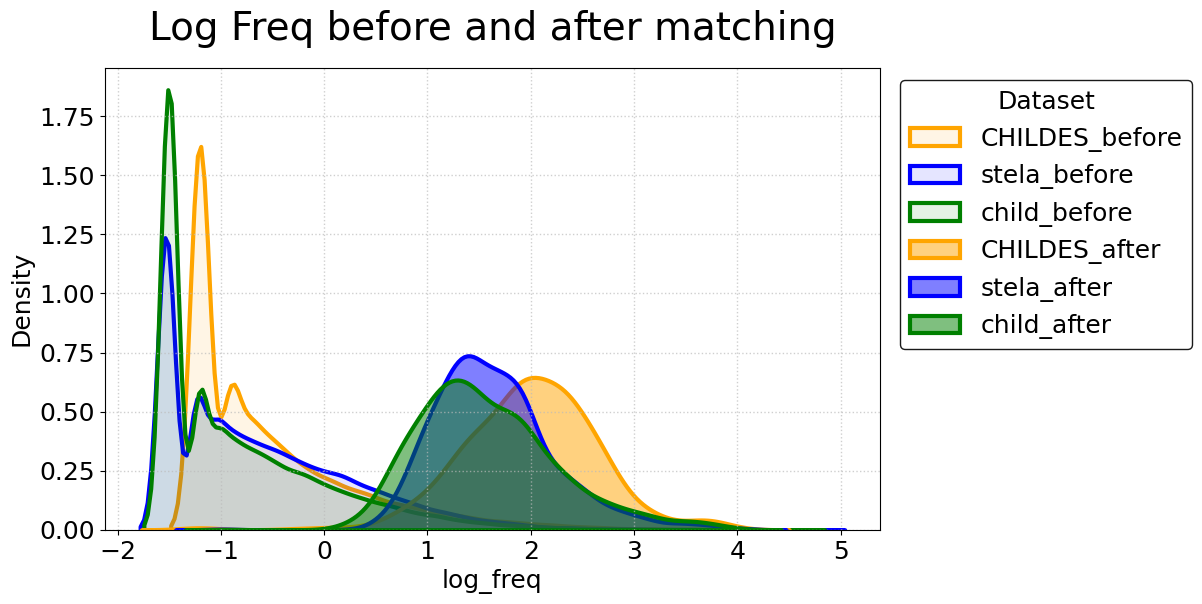

<Figure size 1200x600 with 0 Axes>

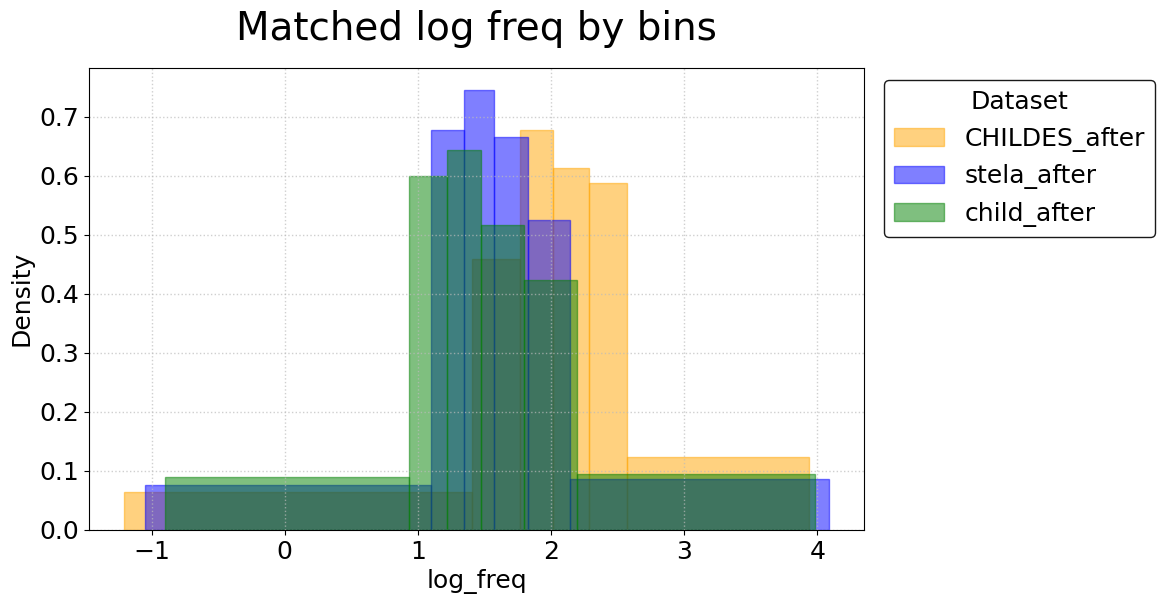

<Figure size 1200x600 with 0 Axes>

In [317]:
# load file
sampling_ratio = 4
file_root = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}"
freq_root = "/Users/jliu/workspace/lexical_bencmark/dataset/word_freq"
cdi_path = "/Users/jliu/workspace/lexical_bencmark/dataset/cdi_ws_na_childes.csv"
compare_distr(file_root, freq_root, cdi_path)

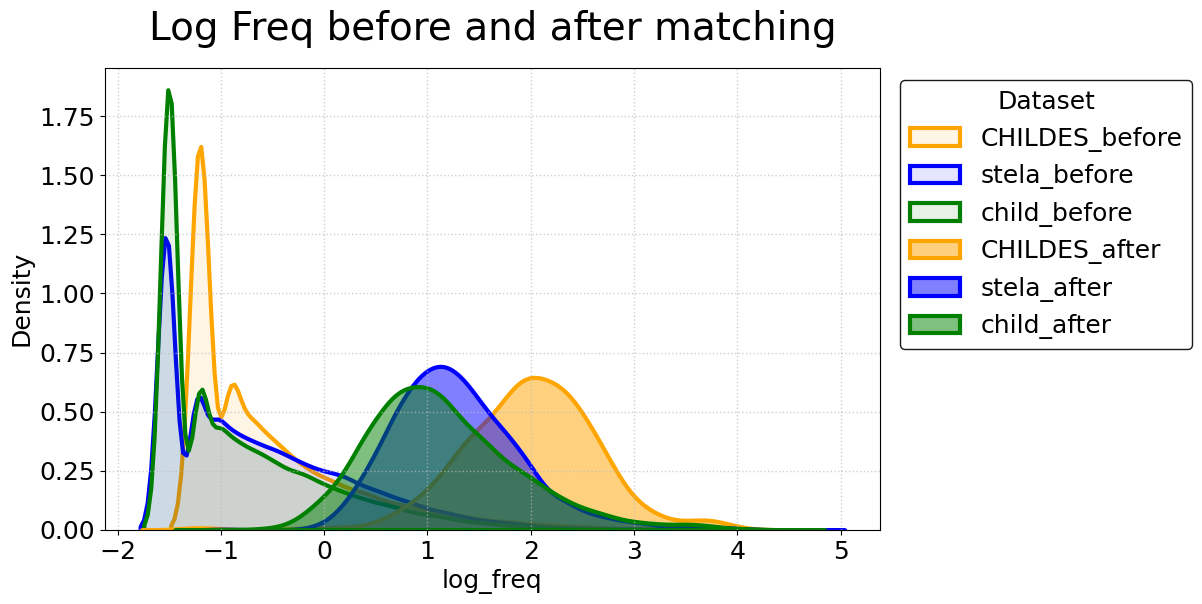

<Figure size 1200x600 with 0 Axes>

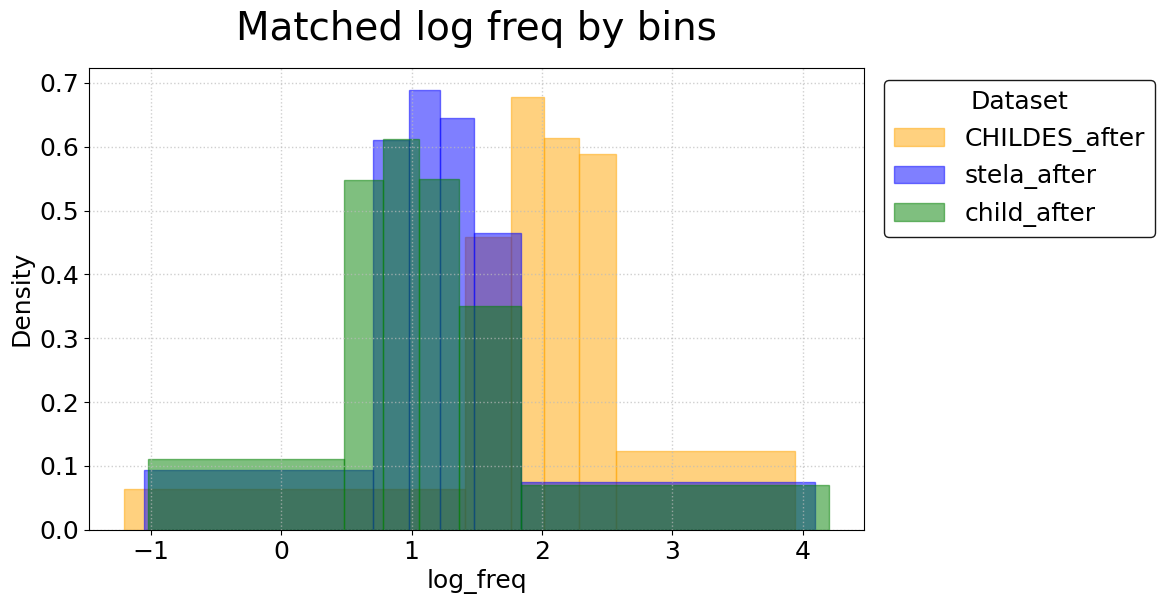

<Figure size 1200x600 with 0 Axes>

In [306]:
# load file
sampling_ratio = 8
file_root = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}"
freq_root = "/Users/jliu/workspace/lexical_bencmark/dataset/word_freq"
cdi_path = "/Users/jliu/workspace/lexical_bencmark/dataset/cdi_ws_na_childes.csv"
compare_distr(file_root, freq_root, cdi_path)

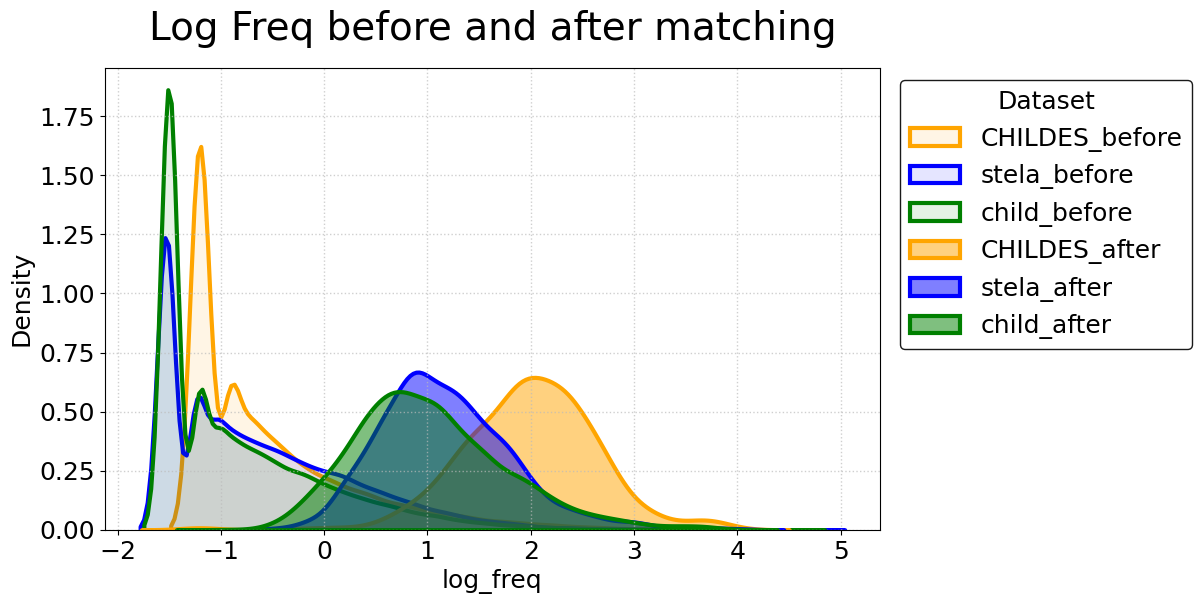

<Figure size 1200x600 with 0 Axes>

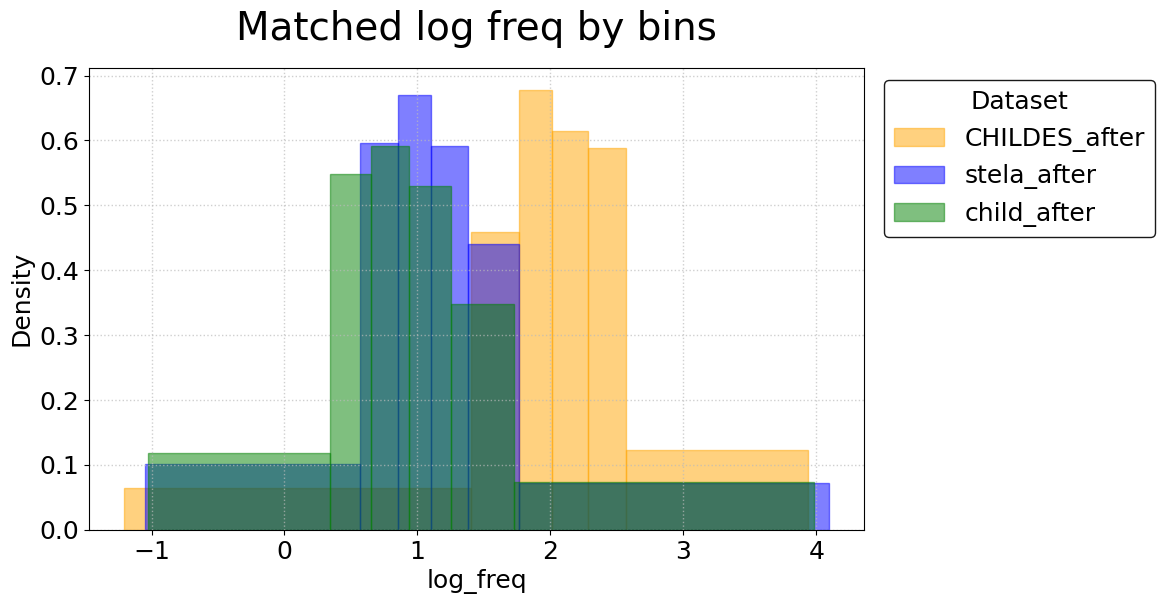

<Figure size 1200x600 with 0 Axes>

In [316]:
# load file
sampling_ratio = 10
file_root = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}"
freq_root = "/Users/jliu/workspace/lexical_bencmark/dataset/word_freq"
cdi_path = "/Users/jliu/workspace/lexical_bencmark/dataset/cdi_ws_na_childes.csv"
compare_distr(file_root, freq_root, cdi_path)

# test CDI thresholds

In [7]:
# load raw data
raw_data_path = "/Users/jliu/workspace/lexical_bencmark/dataset/metric/metric_CDI_threshold_test.csv"
CDI_path = "/Users/jliu/workspace/lexical_bencmark/dataset/CDI/human_CDI.csv"
raw_data = pd.read_csv(raw_data_path)
human = pd.read_csv(CDI_path)
df = raw_data.dropna()
# Sort by month and combine dataset + model_type for labels
df = df.sort_values("month")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jliu/workspace/lexical_bencmark/dataset/CDI/human_CDI.csv'

In [243]:
def calculate_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    # Group by x_col and calculate statistics
    stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()
    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def plot_combined_cdi_curves(human_cdi_path: Path, threshold_path: Path) -> plt.Figure:
    """Plot human CDI development and threshold curves in the same figure."""
    # Create single figure
    fig, ax = plt.subplots(figsize=PlotSettings.DEFAULTS["figsize"])

    # First plot the threshold curves
    df_threshold = pd.read_csv(threshold_path)
    threshold_cols = [col for col in df_threshold.columns if col.startswith("threshold_")]

    threshold_colors = PlotSettings.get_color_palette(len(threshold_cols))

    # Plot threshold curves
    for threshold, color in zip(threshold_cols, threshold_colors):
        stats = calculate_stat(df_threshold, "month", threshold)
        threshold_value = threshold.split("_")[1]

        ax.plot(stats["month"], stats["mean"], label=f"threshold {threshold_value}", color=color, linewidth=PlotSettings.DEFAULTS["linewidth"], linestyle="--")

        ax.fill_between(stats["month"], stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], alpha=0.1, color=color)

    # Plot human CDI development
    df_human = pd.read_csv(human_cdi_path)
    month_cols = [col for col in df_human.columns if (str(col).strip().isnumeric() and int(str(col).strip()) >= 16 and int(str(col).strip()) <= 30)]
    month_cols.sort(key=lambda x: int(x))

    monthly_means = df_human[month_cols].mean()
    monthly_std = df_human[month_cols].std()
    months = [int(col) for col in month_cols]

    # Plot human data
    human_color = "#FF0000"  # Red for human data
    ax.plot(months, monthly_means.values, linewidth=PlotSettings.DEFAULTS["linewidth"], color=human_color, marker="o", label="Human CDI", linestyle="-")

    # Add human confidence interval
    ci = 1.96 * monthly_std / np.sqrt(len(df_human))
    ax.fill_between(months, monthly_means - ci, monthly_means + ci, alpha=0.2, color=human_color)

    # Apply styling
    ax.set_xlabel("Month", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.set_ylabel("CDI Score", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.legend(
        fontsize=PlotSettings.DEFAULTS["label_fontsize"], bbox_to_anchor=(1.05, 1), loc="upper left", title="Data Sources", title_fontsize=PlotSettings.DEFAULTS["label_fontsize"]
    )

    # Apply PlotSettings style
    PlotSettings.apply_style_to_axis(ax, "CDI count-threshold")

    plt.tight_layout()
    return fig


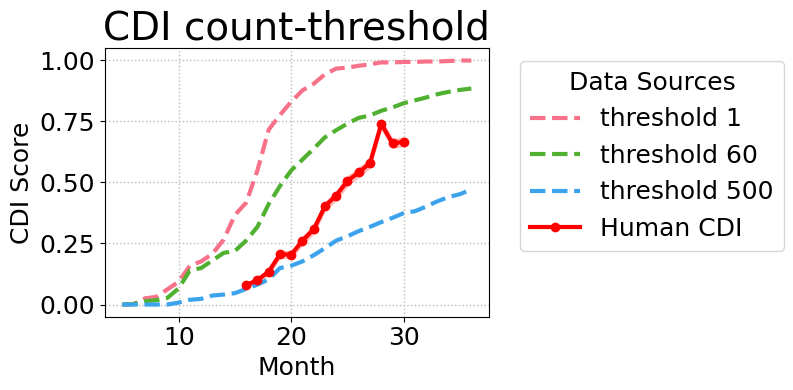

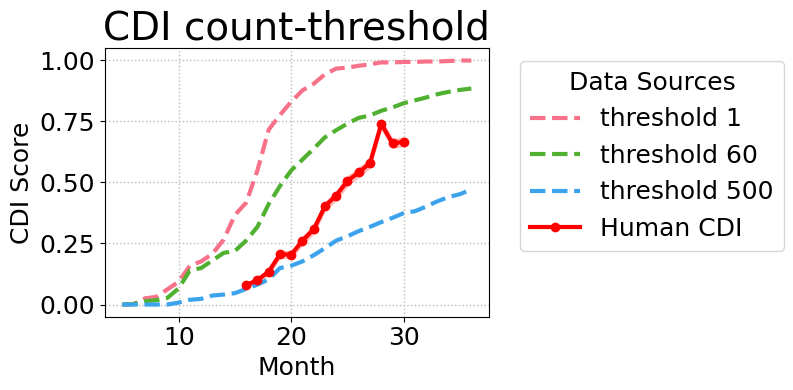

In [244]:
raw_data_path = "/Users/jliu/workspace/lexical_bencmark/dataset/metric/metric_CDI_threshold_test.csv"
CDI_path = "/Users/jliu/workspace/lexical_bencmark/dataset/CDI/human_CDI.csv"
human_cdi_path = Path(CDI_path)
threshold_path = Path(raw_data_path)
# Create the combined plot
plot_combined_cdi_curves(human_cdi_path, threshold_path)


# Core metrics

In [8]:
# load and merge stat in different conditions
def load_df(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Load and aggregate data based on metric while handling duplicates."""
    # Filter temperature
    df = df[df["temp"] == 1.0].copy()

    # Create condition column if not exists
    if "condition" not in df.columns:
        df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    if metric != "CDI":
        # First handle null values appropriately
        df[metric] = df[metric].fillna(method="ffill")

        # Group by month and condition to handle duplicates
        df = (
            df.groupby(["condition", metric]).agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"}).reset_index()
        )

    return df


def calculate_statistics(df: pd.DataFrame, group_header: str, x_header: str, y_header: str) -> pd.DataFrame:
    """Calculate mean, standard deviation, and confidence intervals."""
    stats = df.groupby([group_header, x_header])[y_header].agg(["mean", "std", "count"]).reset_index()

    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str, plot_settings: PlotSettings) -> None:
    """Plot curve for a single condition with confidence interval."""
    # load files
    color_dict = plot_settings.COLORS
    plt.plot(
        subset[x_header],
        subset["mean"],
        label=condition,
        color=color_dict[condition.split("(")[0]],
        linestyle=plot_settings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=plot_settings.DEFAULTS["linewidth"],
    )
    plt.fill_between(subset[x_header], subset["mean"] - subset["ci"], subset["mean"] + subset["ci"], color=color_dict[condition.split("(")[0]], alpha=0.2)


def plot_curves(df: pd.DataFrame, x_header: str, y_header: str, group_header: str, y_lim: list[float] = [0, 1]) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    # Initial plot configuration
    PlotSettings.configure_plot()

    # Calculate statistics
    df_stats = calculate_statistics(df, group_header, x_header, y_header)
    # Get unique conditions and their color mapping
    unique_conditions = df_stats[group_header].unique()
    # Plot each condition
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header, PlotSettings)

    # Configure plot aesthetics
    plt.ylim(y_lim)
    plt.xlabel(x_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_header, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    PlotSettings.configure_legend()
    plt.show()

In [15]:
def plot_all_metrics(raw_data_path: str):
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    x_header = "month"
    group_header = "condition"

    metric_dict = {"type_token_ratio": [0, 1], "rej_type_rate": [0, 0.4], "rej_token_rate": [0, 0.3], "CDI": [0, 1]}
    for metric, ylim in metric_dict.items():
        sel_df = load_df(df, metric=metric)
        plot_curves(sel_df, x_header, metric, group_header, y_lim=ylim)


/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_58957/2706739222.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


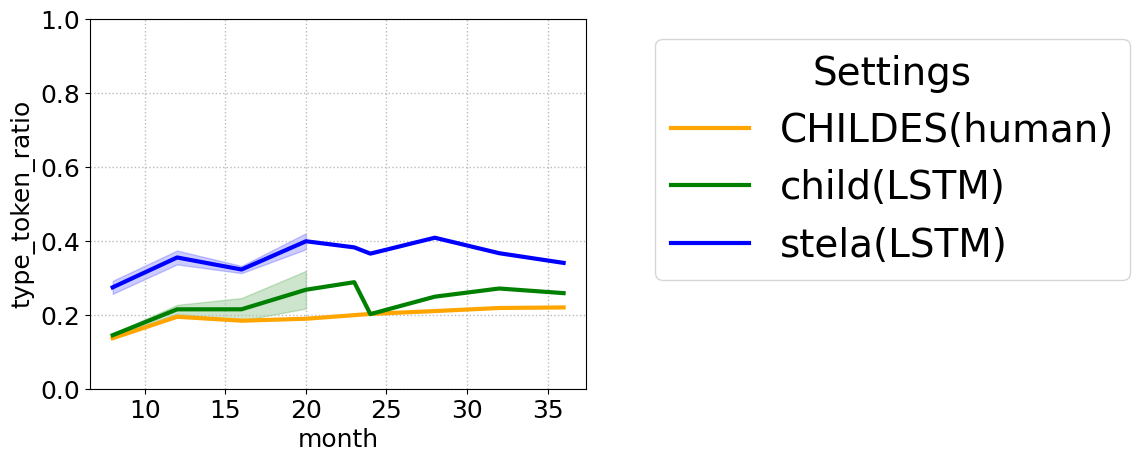

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_58957/2706739222.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


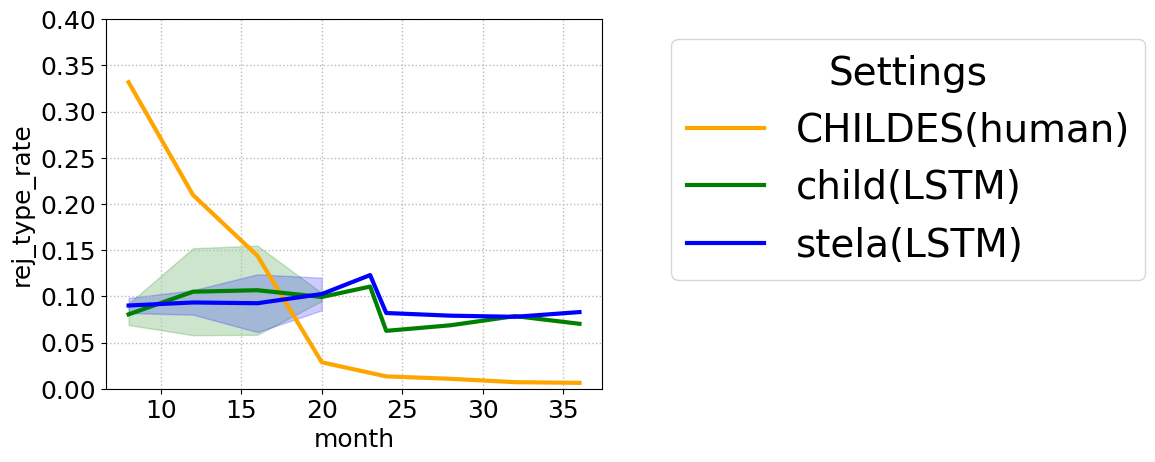

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_58957/2706739222.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


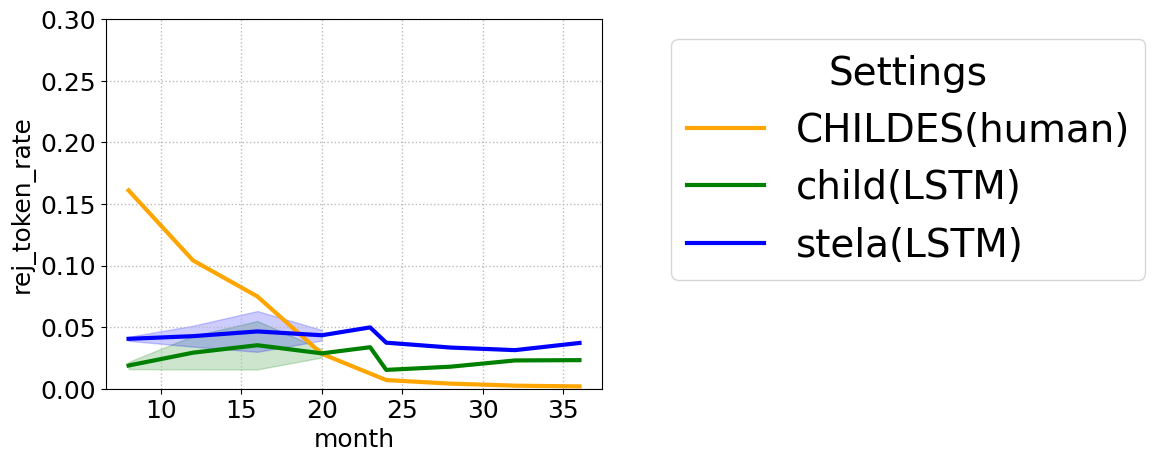

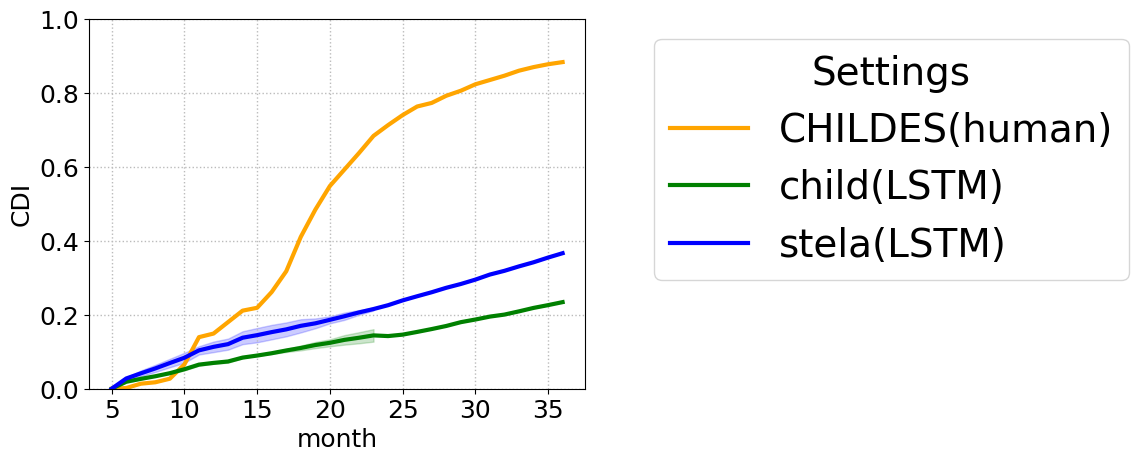

In [16]:
sampling_ratio = 1
raw_data_path = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}/metric_1000_4.csv"
plot_all_metrics(raw_data_path)

# Temperature trade-off 

In [29]:
# Type definitions
DataFrameType = pd.DataFrame
PathType = Path | str
MetricType = dict[str, list[float]]


def load_df(df: DataFrameType, metric: str) -> DataFrameType:
    """
    Load and aggregate data based on metric while handling duplicates.
    """
    # Calculate means for the metric across months for each condition and temperature
    grouped_df = (
        df.groupby(["condition", "temp"])
        .agg(
            {
                metric: "mean",
                "CDI": "mean",  # We always need CDI for x-axis
            }
        )
        .reset_index()
    )

    return grouped_df


def create_scatter_plot(df: DataFrameType, x_metric: str, y_metric: str, plot_settings: t.Any, y_lim: list[float]) -> None:
    """Create scatter plot with mean values and temperature annotations."""
    plt.figure(figsize=plot_settings.DEFAULTS["figsize"])

    # Plot for each condition
    for condition in df["condition"].unique():
        subset = df[df["condition"] == condition]
        base_condition = condition.split("(")[0]
        color = plot_settings.COLORS.get(base_condition, "gray")
        linestyle = plot_settings.LINESTYLES.get(extract_style(condition), "-")

        # Create scatter plot
        plt.scatter(subset[x_metric], subset[y_metric], color=color, label=condition, alpha=0.7, s=100)

        # Add temperature annotations
        for _, row in subset.iterrows():
            plt.annotate(f"{row['temp']:.1f}", (row[x_metric], row[y_metric]), xytext=(10, 5), textcoords="offset points", fontsize=10, color=color)

        # Connect points for same condition
        if len(subset) > 1:
            plt.plot(subset[x_metric], subset[y_metric], color=color, linestyle=linestyle, alpha=0.5)

    # Configure plot settings
    plt.xlabel(x_metric, fontsize=plot_settings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_metric, fontsize=plot_settings.DEFAULTS["label_fontsize"])
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.ylim(y_lim)
    plot_settings.configure_legend()


def extract_style(text: str) -> str:
    """Extract text inside parentheses."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""


class PlotSettings:
    """Class to manage plot styling and configuration."""

    COLORS: dict[str, str] = {
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {"LSTM": "-", "trans": "-."}

    DEFAULTS = {
        "label_fontsize": 18,
        "linewidth": 3,
        "title_fontsize": 28,
        "grid_color": "#bbbbbb",
        "figsize": (10, 6),
    }

    @classmethod
    def configure_legend(cls) -> None:
        """Configure legend settings."""
        plt.legend(title="Settings", title_fontsize=cls.DEFAULTS["title_fontsize"], fontsize=cls.DEFAULTS["label_fontsize"], loc="upper left", bbox_to_anchor=(1.1, 1))


def plot_all_metrics(raw_data_path: PathType) -> None:
    """
    Plot all metrics against CDI with temperature annotations.
    """
    # Load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()

    # Sort by month and create condition labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    # Define metrics and their y-axis limits
    metric_dict: MetricType = {
        "type_token_ratio": [0, 1],
        "rej_type_rate": [0, 0.4],
        "rej_token_rate": [0, 0.3],
    }

    # Create plots for each metric
    for metric, y_lim in metric_dict.items():
        sel_df = load_df(df, metric=metric)
        create_scatter_plot(sel_df, x_metric="CDI", y_metric=metric, plot_settings=PlotSettings, y_lim=y_lim)
        plt.show()


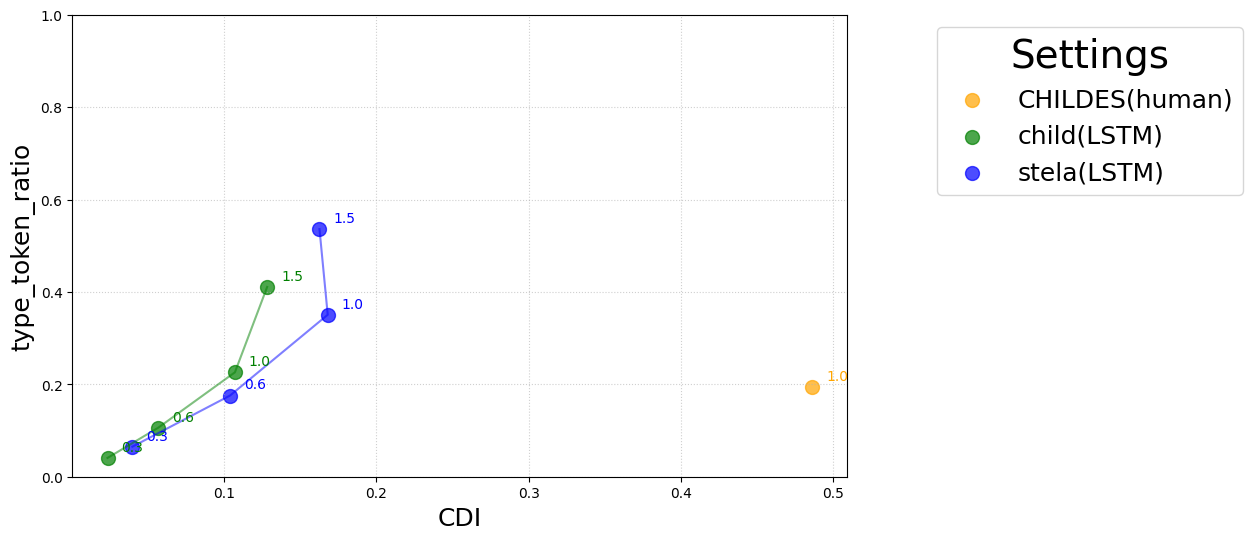

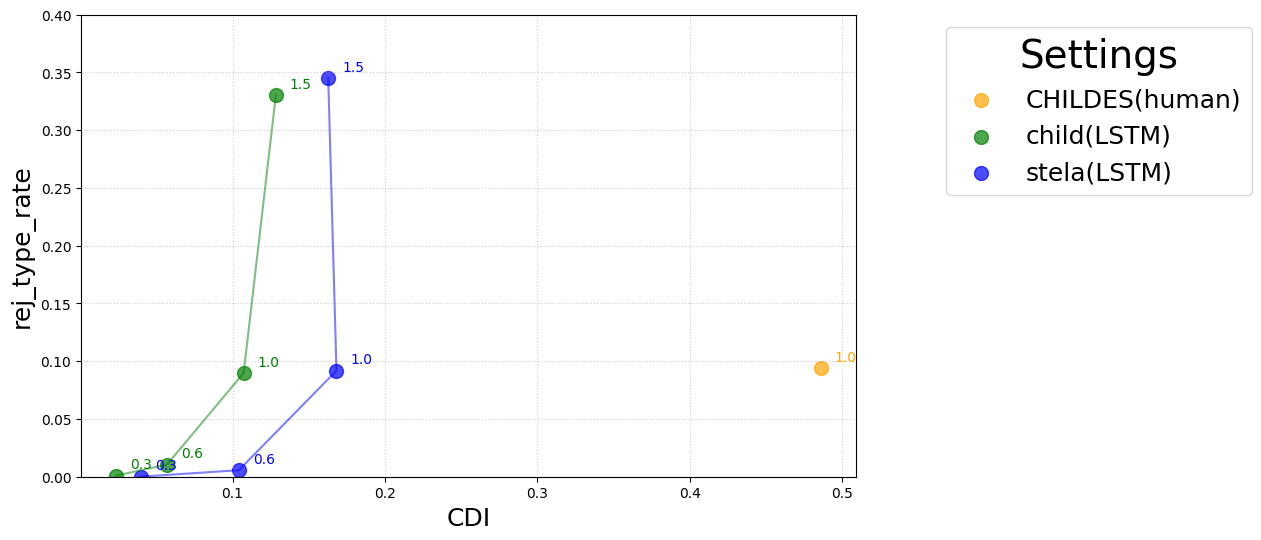

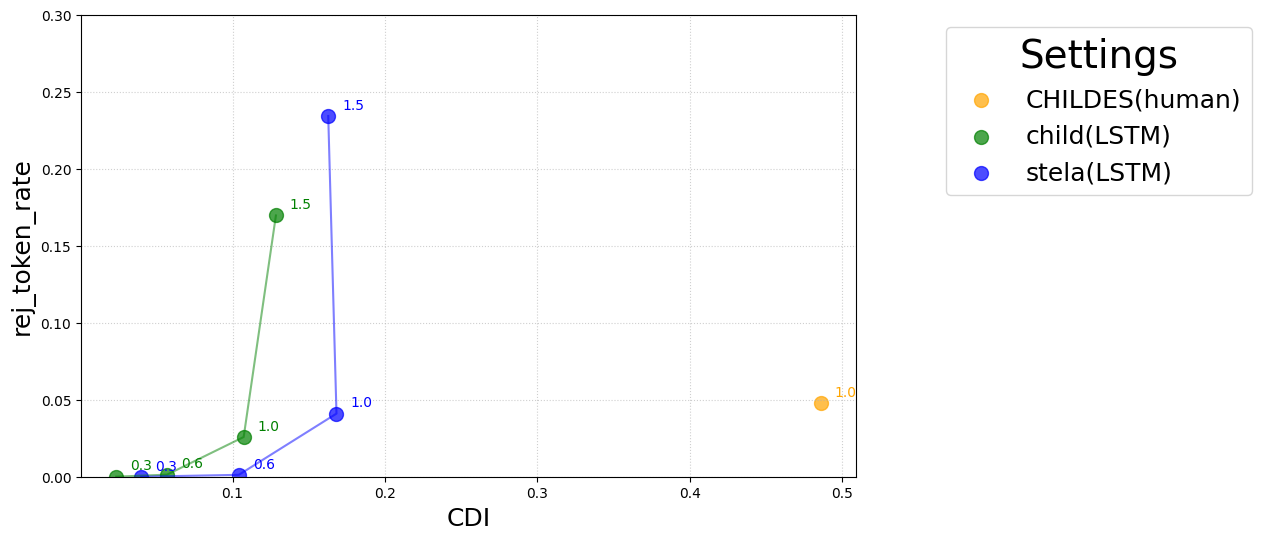

In [30]:
sampling_ratio = 1
raw_data_path = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}/metric_1000_4.csv"
temperatures = [0.3, 0.6, 1.0, 1.5]

data_path = Path(raw_data_path)
plot_all_metrics(data_path)

# Extrapolated metrics

Fitting Results:
Target X: 27.27
Steepness (k): 0.1995
Midpoint (x0): 20.3292


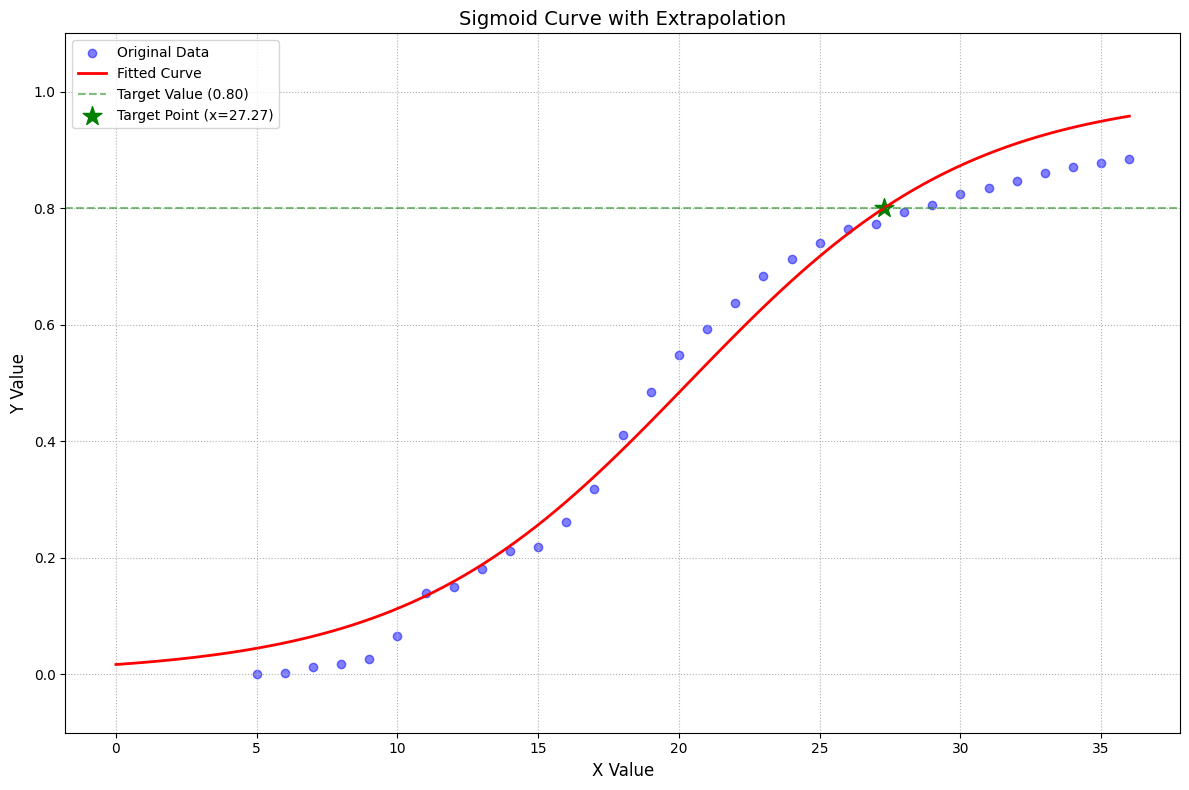

In [336]:
from scipy.optimize import curve_fit


class SigmoidFitter:
    """Fit and plot sigmoid curves with extrapolation to target value."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float) -> None:
        """Initialize the sigmoid fitter with data and target."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """
        Compute normalized sigmoid function: 1/(1 + exp(-k*(x-x0)))

        Args:
            x: Input values
            k: Steepness of the curve
            x0: x-value of sigmoid midpoint
        Returns:
            y: Values in range [0,1]
        """
        return 1 / (1 + np.exp(-k * (x - x0)))

    def estimate_initial_params(self) -> tuple[list[float], tuple[tuple[float, float], ...]]:
        """Estimate initial parameters and bounds for curve fitting."""
        # Estimate x0 (midpoint)
        y_mid = (max(self.y_data) - min(self.y_data)) / 2 + min(self.y_data)
        x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]

        # Estimate k (steepness)
        mid_idx = np.argmin(np.abs(self.x_data - x0_init))
        if mid_idx > 0 and mid_idx < len(self.x_data) - 1:
            dy = self.y_data[mid_idx + 1] - self.y_data[mid_idx - 1]
            dx = self.x_data[mid_idx + 1] - self.x_data[mid_idx - 1]
            k_init = (dy / dx) * 4  # Scale factor for sigmoid shape
        else:
            k_init = 0.1

        # Initial parameter guesses
        p0 = [k_init, x0_init]

        # Parameter bounds
        bounds = (
            (0.001, 2.0),  # k bounds: shallow to steep
            (min(self.x_data), max(self.x_data) * 1.5),  # x0 bounds
        )

        return p0, bounds

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid and find target x value."""
        # Get initial parameters and bounds
        p0, bounds = self.estimate_initial_params()

        # Fit sigmoid curve with bounds and initial guesses
        popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

        # Generate fitted points with finer resolution
        x_fit = np.linspace(0, max(self.x_data), 100)
        y_fit = self.sigmoid(x_fit, *popt)

        # Extrapolate if needed
        if max(self.y_data) < self.target_y:
            while y_fit[-1] < self.target_y:
                next_x = x_fit[-1] + (x_fit[1] - x_fit[0])
                x_fit = np.append(x_fit, next_x)
                y_fit = np.append(y_fit, self.sigmoid(next_x, *popt))

                if y_fit[-1] >= self.target_y or len(x_fit) > 1000:
                    break

        # Find target point
        target_y_index = np.argmin(np.abs(y_fit - self.target_y))
        target_x = x_fit[target_y_index]

        self.params = {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        return {"target_x": target_x, "k": popt[0], "x0": popt[1]}

    def plot_curve(self, title: str = "Sigmoid Curve with Extrapolation", output_path: Path | None = None) -> None:
        """Plot the fitted sigmoid curve with extrapolation."""
        if not self.params:
            self.fit_sigmoid()

        plt.figure(figsize=(12, 8))

        # Plot original data points
        plt.scatter(self.x_data, self.y_data, color="blue", alpha=0.5, label="Original Data")

        # Plot fitted curve
        plt.plot(self.params["x_fit"], self.params["y_fit"], "r-", label="Fitted Curve", linewidth=2)

        # Plot target line and point
        plt.axhline(y=self.target_y, color="green", linestyle="--", alpha=0.5, label=f"Target Value ({self.target_y:.2f})")
        plt.scatter(self.params["target_x"], self.target_y, color="green", marker="*", s=200, label=f"Target Point (x={self.params['target_x']:.2f})")

        # Customize plot
        plt.grid(True, linestyle=":")
        plt.title(title, fontsize=14)
        plt.xlabel("X Value", fontsize=12)
        plt.ylabel("Y Value", fontsize=12)
        plt.legend(fontsize=10)
        plt.ylim(-0.1, 1.1)  # Set y-axis limits to show full [0,1] range

        plt.tight_layout()
        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()


def test_sigmoid_fitter() -> None:
    """Test the SigmoidFitter class with sample data."""
    # Generate sample data

    frame = pd.read_csv(threshold_path)
    x_data = frame["month"]
    y_data = frame["threshold_60"]

    target_y = 0.8

    # Create and fit sigmoid
    fitter = SigmoidFitter(x_data, y_data, target_y)
    results = fitter.fit_sigmoid()

    print("Fitting Results:")
    print(f"Target X: {results['target_x']:.2f}")
    print(f"Steepness (k): {results['k']:.4f}")
    print(f"Midpoint (x0): {results['x0']:.4f}")

    # Plot results
    fitter.plot_curve()


In [ ]:
# TODO: different freq bands

# Case study

## scatter plot of different vocab distr

In [114]:
def load_count(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)
    return all_count


# load data recursively
def load_files(freq_ROOT: str) -> list:
    all_count = []
    # load all the generated sets
    files = os.listdir(freq_ROOT)
    files = sorted(files)
    for file in files:
        if file.endswith(".csv"):
            word_count = TokenCount()
            word_count.df = pd.read_csv(f"{freq_ROOT}{file}")
            word_count.name = file[:-4].split("_")[-1]
            all_count.append(word_count)

    # divide into different types of sets
    gen_count = []
    unwanted_lst = ["train", "child", "adult"]
    for tc in all_count:
        if tc.name not in unwanted_lst:
            gen_count.append(tc)
        if tc.name == "train":
            ref_count = tc
        else:
            pass
    return all_count, ref_count, gen_count

In [116]:
def line_plot(data, fig_path: str, prompt_type: str, model: str, xlog=True, ylim=[0, 1]):
    """Generic line plotting function; data is a dictionnary associating a name with a dataframe with two columns
    (the first one for x, the second one for y)
    """
    # plt.figure(figsize=(10, 5))  # Set the size of the plot

    for key in data:
        df = data[key]
        xname = df.columns[0]
        yname = df.columns[1]
        aggregated_df = df.groupby(xname)[yname].mean().reset_index()
        if key == "ind" or key == "ood":
            linetyle = "-"
            linewidth = 3.5
        else:
            linetyle = "-"
            linewidth = 3
        plt.plot(aggregated_df[xname], aggregated_df[yname], linewidth=linewidth, linestyle=linetyle, label=key, color=color_dict[key])

    plt.xlabel(xname, fontsize=20)  # Label for the x-axis
    plt.ylabel(yname, fontsize=20)  # Label for the y-axis
    plt.ylim(ylim)
    # plt.axhline(y=0, color='red', linestyle='--',linewidth=3.5, label='y = 0')
    if xlog:
        plt.xscale("log")


def tc_plot_miss_oov_rates(ref_count: TokenCount, gen_count_list: list, set_name: str, fig_path: str, prompt_type: str, model: str, groupbin=50):
    """
     Plots three curves regarding missing words and oovs

    :param ref_count: a reference TokenCount
    :param gen_count_list: a list of generated or test TokenCount
    :param groupbin:
    :return: dataframe containing different scores
    """
    pmiss = {}
    poov = {}

    for gen_count in gen_count_list:
        msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=groupbin)
        if set_name == "pmiss":
            pmiss[gen_count.name] = msc[["medcount", "pmiss"]]
            line_plot(pmiss, fig_path + "M.png", prompt_type, model)
        elif set_name == "oov":
            poov[gen_count.name] = osc[["medcount", "poov"]]
            line_plot(poov, fig_path + "O.png", prompt_type, model)
    return msc, osc, nsc

In [11]:
def scatter_hist_shade(ref_count: TokenCount, gen_count: TokenCount, model: str, ax, ax_histx, ax_histy, color_dict, num, log, bins=100, alpha_val=0.5):
    # Scatter plot with varying transparency (alpha) and edge color
    newdf = pd.merge(ref_count.df[["word", "count"]], gen_count.df[["word", "count"]], on="word", how="outer")
    newdf.set_index("word", inplace=True)
    newdf.columns = ["ref_count", "gen_count"]
    withoutoovdf = newdf[newdf["ref_count"].notna()]

    # Vary the transparency for each dataset
    ax.scatter(withoutoovdf["ref_count"], withoutoovdf["gen_count"], color=color_dict[num], alpha=alpha_val, label=f"{num}x")

    maxx = max(withoutoovdf["gen_count"])
    ax.plot([0, maxx], [0, maxx], color="r", alpha=1)

    # Plot the missing word rates by frequency
    msc, osc, nsc = tc_compute_miss_oov_rates(ref_count, gen_count, groupbin=50)

    aggregated_df_miss = msc.groupby("medcount")["pmiss"].mean().reset_index()
    ax_histx.plot(aggregated_df_miss["medcount"], aggregated_df_miss["pmiss"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histx.invert_yaxis()

    aggregated_df_oov = osc.groupby("medcount")["poov"].mean().reset_index()
    ax_histy.plot(aggregated_df_oov["poov"], aggregated_df_oov["medcount"], linewidth=3.5, linestyle="-", color=color_dict[num])

    # ax_histy.invert_xaxis()

    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
        # ax_histx.set_yscale("log")
        ax_histy.set_yscale("log")
        ax_histx.set_xscale("log")
        # ax_histy.set_xscale("log")

    # Set axis range for histograms (side bars)
    ax_histx.set_ylim(0, 1)  # Set x-axis range for the top histogram
    ax_histy.set_xlim(0, 1)  # Set y-axis range for the left histogram
    # save the figure to the required directory
    plt.savefig(Path(fig_ROOT) / f"distr_{model[:5]}_{gen_count.name}.png", dpi=300, bbox_inches="tight")
    return newdf, maxx


/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  newdf['correct'].fillna(newdf['ref_correct'], inplace=True)
/Users/jliu/PycharmProjects/Lexical-benchmark/scripts/lm_benchmark/plot_util.py:274: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting',

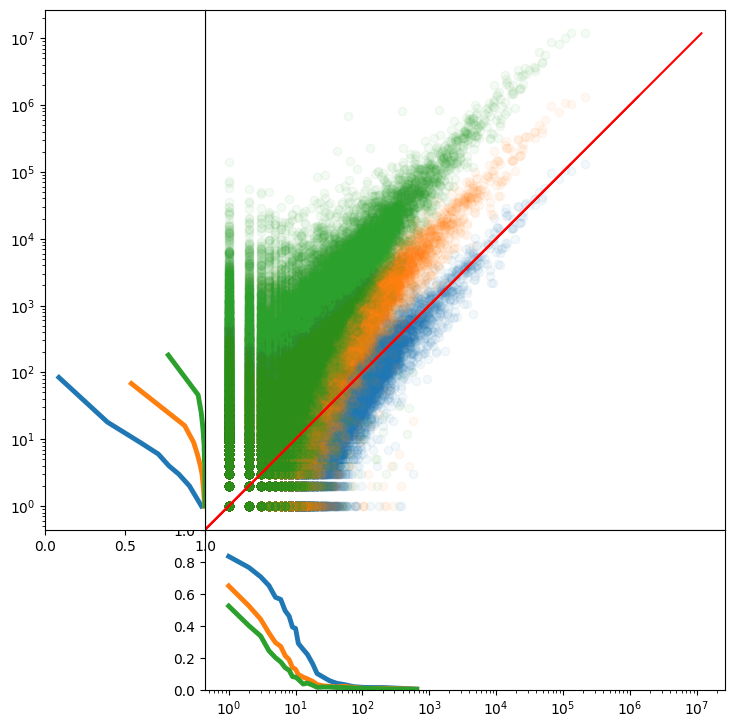

In [12]:
filename_lst = ["1", "10", "100"]
prompt_type = "unprompted"
color_dict = {
    "1": "#1f77b4",  # Blue
    "10": "#ff7f0e",  # Orange
    "100": "#2ca02c",  # Green
}

log = True
model = "LSTM"

# Create the figure once, outside the loop
fig = plt.figure(figsize=(8, 8))

# Axes locations for subplots, we will reuse them across the loop
left, width = 0.3, 0.65
bottom, height = 0.1, 0.65
spacing = 0

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom - spacing - 0.2, width, 0.2]
rect_histy = [left - spacing - 0.2, bottom, 0.2, height]

# Create ax once, and reuse for each dataset
ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)

diag_lines = {}
# Loop over each dataset
for idx, filename in enumerate(filename_lst):
    freq_ROOT = f"{ROOT}/datasets/processed/freq/{prompt_type}_{model}_400_{filename}/"
    all_count, ref_count, gen_count_lst = load_files(freq_ROOT)

    # Set alpha transparency value: Start with 0.8 and reduce for each subsequent dataset
    alpha_val = 0.05
    newdf, maxx = scatter_hist_shade(ref_count, gen_count_lst[0], model, ax, ax_histx, ax_histy, color_dict, filename, log, alpha_val=alpha_val)

# Add legend and display the figure

plt.show()
